# Final project
## Outline of explainer notebook

### 1. Motivation

### 2. Basic stats
    2.1 Data request and scoping

    2.1 Data cleaning and preprocessing

    2.2 Building semantic co-occurrence networks

    2.3 Dataset stats

### 3. Tools, tehory and analysis
    3.1 Network analysis and visualization

    3.2 Descriptive analysis

### 4. Discussion
    4.1 Results and discussion
    
    4.2 Bias and ethics

---

## 1. Motivation

### What is your dataset?

The dataset consists of Wikipedia biographies of scientists across five fields: computer science, physics, chemistry, mathematics, and biology. The biographies are retrieved using Wikidata, where individuals are filtered by occupation and gender, and then linked to their corresponding English Wikipedia articles.

From these articles, we extract the full text and apply preprocessing to clean and standardize the content. The final dataset is balanced across gender and field, ensuring that each subgroup is equally represented.

---

### Why did you choose this dataset?

Wikiepedia is an open source, globally known. It is collaboratively written. 

Wikipedia biographies provide a rich and accessible source of textual data that reflects how individuals are described and represented publicly. Because Wikipedia is collaboratively written, it can reveal broader patterns in how different groups are portrayed.

We chose this dataset to investigate potential differences in how male and female scientists are described. In particular, we are interested in whether there are systematic differences in the emphasis on:

- scientific contributions  
- institutional affiliations  
- personal life and family context  

By selecting multiple scientific fields and balancing the dataset, we aimm to ensure that any observed differences are not driven by discipline-specific biases or uneven representation.

---

### What was your goal for the end user’s experience?


The goal is to provide an intuitive and engaging exploration of how language differs across biographies of women and men scientists.

For the end user, we aim to:

- make complex text analysis understandable through clear visualizations  
- highlight meaningful patterns in how scientists are described  
- communicate insights in a way that is accessible to any audience

The user should come away with an understanding of how narratives differ between groups, supported by both quantitative analysis and visually:)


# 2. Basic stats
## 2.1 Data requests and scoping

We begin by querying Wikidata using its SPARQL endpoint. For each scientific field (computer science, physics, chemistry, mathematics, and biology), we retrieve individuals who satisfy three conditions:
- They are instances of a human (`wdt:P31 wd:Q5`)
- They have a specified gender (`wdt:P21`)
- They have a given occupation (`wdt:P106`)
Additionally, we restrict the results to individuals with an English Wikipedia article. This ensures that we can later retrieve textual data for analysis.
We perform separate queries for men and women and limit the number of returned individuals per field and gender group. This initial cap (e.g., 300 per group) is intentionally generous, as some biographies will later be filtered out.
Using Wikidata in this way allows us to systematically construct a dataset that is both structured and reproducible.


For each individual returned from Wikidata, we extract the corresponding Wikipedia article title and use the Wikipedia API to retrieve the full article text.
Articles are fetched one by one rather than in batches. A small delay is introduced between requests to respect API rate limits.
At this stage, we compute simple diagnostics:
- total number of retrieved individuals
- number of empty articles
- number of articles exceeding a minimum length threshold


Not all Wikipedia biographies are suitable for textual analysis. Very short articles can lack meaningful content and may introduce noise. Upon investigating short biographies they are largely dominated by birth year and instituions. Is this a biased step
We therefore apply a filtering step:
- Only articles with at least 500 words are retained
This threshold ensures that each biography contains sufficient information for a more meaninful (what does this even mean)semantic analysis, such as TF-IDF and co-occurrence networks.
After filtering, we inspect how many biographies remain per field and gender group.



The number of valid biographies is not evenly distributed across fields and genders. To ensure a fair comparison, we construct a balanced dataset.
We group the filtered biographies by:
- scientific field
- gender
We then sample the same number of biographies from each group. Specifically, we take the minimum available count across all groups and randomly sample that many biographies from each group.
This ensures that:
- each field contributes equally
- each gender is equally represented within each field
Random sampling is performed with a fixed random seed to ensure reproducibility.
---


The final dataset consists of a balanced collection of Wikipedia biographies across multiple scientific fields and genders. For each biography, we retain:
- name and metadata (field, gender)
- article title and URL
- full text
- word count
This dataset serves as the foundation for all subsequent analysis, including text preprocessing, TF-IDF feature extraction, and semantic network construction.



## 2.2 Data cleaning and preprocessing

### Removing non-biographical sections

The first preprocessing step removes sections that are not central to the biography itself. These include:

- `References`
- `Bibliography`
- `Further reading`
- `External links`
- `Selected publications`
- `Awards and honors`

This helps ensure that the analysis focuses on the narrative/personal content of the biography rather than citation metadata, lists of publications, or external resources.

We also remove words from the article title, such as the person’s first and last name. For example, in the article `Ada Lovelace`, the words `ada` and `lovelace` are removed. This is important because a biography naturally repeats the subject’s name many times. If we kept these names, they could dominate the word counts and networks without providing meaningful information about how the person is described. This was made apparaent in the initial faces where people suck as Ada Lovelace and Einstein dominated the analysis

### Basic text cleaning

The text is then standardized by:

1. converting all letters to lowercase  
2. removing remaining Wikipedia headings  
3. removing punctuation, numbers, and special characters  
4. keeping only alphabetic words  
5. collapsing extra spaces  

### Stopword removal

Next, we remove stopwords. Stopwords are common words such as `the`, `and`, `is`, and `of`, which occur frequently but usually carry little semantic meaning. We use the English stopword list from `NLTK` and extend it with custom stopwords that are especially relevant for Wikipedia biographies. These include citation-related words such as `isbn`, `doi`, and `retrieved`, as well as generic biography words such as `born`, `died`, `year`, and `published`. (is this a good idea)

This helps focus the analysis on more meaningful words.
After cleaning, each biography is tokenized. Tokenization means splitting the text into individual words. The resulting tokens are stored in a new column called `tokens`.

### Creating cleaned text for later analysis

Some methods, such as TF-IDF, expect each document to be represented as a single string rather than a list of tokens. Therefore, the cleaned tokens are joined back together into a string and stored in the column `clean_text`.

This gives us two useful representations:

- `tokens`: useful for word counting and frequency analysis  
- `clean_text`: useful for TF-IDF and vectorized text analysis  

### Preprocessing diagnostics

Finally, we calculate the cleaned word count for each biography. This allows us to check how much text remains after preprocessing and whether the biographies are still long enough for meaningful analysis.

The resulting `clean_word_count` column is later used for a descriptive analysis.

In [ ]:
import requests
import pandas as pd
import time
from tqdm import tqdm
from urllib.parse import unquote

WIKIPEDIA_URL = "https://en.wikipedia.org/w/api.php"
WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"

HEADERS = {
    "User-Agent": "DTU-Student-Project/1.0 (miapaarup@gmail.com)"
}

FEMALE = "Q6581072"
MALE = "Q6581097"

FIELDS = {
    "computer_scientist": "Q82594",
    "physicist": "Q169470",
    "chemist": "Q593644",
    "mathematician": "Q170790",
    "biologist": "Q864503",
}


def query_wikidata_by_field(gender_qid, occupation_qid, field_name, limit=100, retries=3):
    """
    Query Wikidata for people with:
    - selected gender
    - selected occupation
    - English Wikipedia article
    """

    query = f"""
    SELECT ?person ?personLabel ?article WHERE {{
      ?person wdt:P31 wd:Q5;
              wdt:P21 wd:{gender_qid};
              wdt:P106 wd:{occupation_qid}.

      ?article schema:about ?person;
               schema:isPartOf <https://en.wikipedia.org/>.

      SERVICE wikibase:label {{
        bd:serviceParam wikibase:language "en".
      }}
    }}
    LIMIT {limit}
    """

    params = {"query": query, "format": "json"}

    for attempt in range(retries):
        try:
            response = requests.get(
                WIKIDATA_SPARQL_URL,
                params=params,
                headers=HEADERS,
                timeout=90
            )

            print(f"{field_name} | {gender_qid} | attempt {attempt + 1} | status: {response.status_code}")

            if response.status_code != 200:
                print(response.text[:500])
                time.sleep(5)
                continue

            data = response.json()
            rows = []

            for item in data["results"]["bindings"]:
                article_url = item["article"]["value"]

                # Convert Wikipedia URL into clean article title
                title = article_url.split("/wiki/")[-1]
                title = unquote(title)
                title = title.replace("_", " ")

                rows.append({
                    "person": item["person"]["value"],
                    "name": item["personLabel"]["value"],
                    "article_url": article_url,
                    "title": title,
                    "field": field_name
                })

            return pd.DataFrame(rows)

        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
            time.sleep(10)

    return pd.DataFrame()


def get_page_text(title, retries=3):
    """
    Fetch one Wikipedia article text.

    This is less clever than batching, but more reliable.
    """

    params = {
        "action": "query",
        "prop": "extracts",
        "explaintext": True,
        "titles": title,
        "format": "json",
        "redirects": 1
    }

    for attempt in range(retries):
        try:
            response = requests.get(
                WIKIPEDIA_URL,
                params=params,
                headers=HEADERS,
                timeout=60
            )

            if response.status_code != 200:
                print(f"Wikipedia error for {title}: {response.status_code}")
                time.sleep(5)
                continue

            data = response.json()
            pages = data["query"]["pages"]

            for page in pages.values():
                return page.get("extract", "")

        except requests.exceptions.RequestException as e:
            print(f"Request failed for {title}: {e}")
            time.sleep(5)

    return ""




all_people = []

PEOPLE_PER_FIELD_GENDER = 500

for field_name, occupation_qid in FIELDS.items():

    women_field = query_wikidata_by_field(
        gender_qid=FEMALE,
        occupation_qid=occupation_qid,
        field_name=field_name,
        limit=PEOPLE_PER_FIELD_GENDER
    )
    women_field["gender_group"] = "women"

    men_field = query_wikidata_by_field(
        gender_qid=MALE,
        occupation_qid=occupation_qid,
        field_name=field_name,
        limit=PEOPLE_PER_FIELD_GENDER
    )
    men_field["gender_group"] = "men"

    all_people.append(women_field)
    all_people.append(men_field)

    time.sleep(1)

people = pd.concat(all_people, ignore_index=True)
people = people.drop_duplicates(subset=["person"]).reset_index(drop=True)

print("\nCounts before fetching text:")
print(people.groupby(["field", "gender_group"]).size())



texts = []

print("\n--- Fetching article texts one by one ---")

for _, row in tqdm(people.iterrows(), total=len(people)):
    text = get_page_text(row["title"])
    texts.append(text)

    # Polite pause so we do not spam the API
    time.sleep(0.1)

people["text"] = texts
people["text_length"] = people["text"].str.len()
people["word_count"] = people["text"].str.split().str.len()

print("\nText fetching diagnostics:")
print("Total people:", len(people))
print("Articles with empty text:", (people["word_count"] == 0).sum())
print("Articles with at least 500 words:", (people["word_count"] >= 500).sum())




MIN_WORDS = 500

people_filtered = people[people["word_count"] >= MIN_WORDS].copy()

print("\nCounts after filtering short articles:")
print(people_filtered.groupby(["field", "gender_group"]).size())

print("\nFiltered dataset preview:")
print(people_filtered[["name", "gender_group", "field", "title", "word_count"]])




people_filtered.to_csv("scientist_biographies_wikipedia.csv", index=False)

print("\nSaved dataset as scientist_biographies_wikipedia.csv")
print("Total articles kept:", len(people_filtered))
print("Total words:", people_filtered["word_count"].sum())
print("Average words per article:", people_filtered["word_count"].mean())




available_counts = people_filtered.groupby(["field", "gender_group"]).size()

print("\nAvailable biographies per field/gender:")
print(available_counts)

N_PER_GROUP = available_counts.min()

print("\nBalancing to this many biographies per field/gender:")
print(N_PER_GROUP)

balanced_people = (
    people_filtered
    .groupby(["field", "gender_group"], group_keys=False)
    .apply(lambda x: x.sample(n=N_PER_GROUP, random_state=42))
    .reset_index(drop=True)
)

balanced_people.to_csv("balanced_scientist_biographies_wikipedia.csv", index=False)

print("\nSaved balanced dataset as balanced_scientist_biographies_wikipedia.csv")

print("\nBalanced dataset counts:")
print(balanced_people.groupby(["field", "gender_group"]).size())

print("\nFinal balanced dataset size:", len(balanced_people))
print("Total words in balanced dataset:", balanced_people["word_count"].sum())

computer_scientist | Q6581072 | attempt 1 | status: 200
computer_scientist | Q6581097 | attempt 1 | status: 200
physicist | Q6581072 | attempt 1 | status: 200
physicist | Q6581097 | attempt 1 | status: 200
chemist | Q6581072 | attempt 1 | status: 200
chemist | Q6581097 | attempt 1 | status: 200
mathematician | Q6581072 | attempt 1 | status: 200
mathematician | Q6581097 | attempt 1 | status: 200
biologist | Q6581072 | attempt 1 | status: 200
biologist | Q6581097 | attempt 1 | status: 200

Counts before fetching text:
field               gender_group
biologist           men             470
                    women           474
chemist             men             425
                    women           454
computer_scientist  men             500
                    women           500
mathematician       men             375
                    women           404
physicist           men             491
                    women           484
dtype: int64

--- Fetching article texts one 

100%|██████████| 4577/4577 [1:22:53<00:00,  1.09s/it]



Text fetching diagnostics:
Total people: 4577
Articles with empty text: 0
Articles with at least 500 words: 2671

Counts after filtering short articles:
field               gender_group
biologist           men             313
                    women           285
chemist             men             222
                    women           265
computer_scientist  men             307
                    women           250
mathematician       men             201
                    women           196
physicist           men             344
                    women           288
dtype: int64

Filtered dataset preview:
                                name gender_group               field  \
0                       Ada Lovelace        women  computer_scientist   
1              Erna Schneider Hoover        women  computer_scientist   
2                    Mary Lou Jepsen        women  computer_scientist   
3                     Marlyn Meltzer        women  computer_scientist   
4       

C:\Users\miapa\AppData\Local\Temp\ipykernel_28136\1929109223.py:246: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=N_PER_GROUP, random_state=42))


In [ ]:
import re
import itertools
import pandas as pd
import networkx as nx
import nltk

from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("stopwords")


nltk_stop_words = set(stopwords.words("english"))


def remove_bad_sections(text):
    """
    Remove Wikipedia sections that are usually not part of the biography itself.

    This helps avoid analyzing reference lists, publication lists,
    external links, bibliography sections, etc.
    """

    bad_sections = {
        "References",
        "Bibliography",
        "Further reading",
        "External links",
        "See also",
        "Notes",
        "Sources",
        "Works cited",
        "Selected publications",
        "Publications",
        "Books",
        "Awards and honors"
    }

    lines = str(text).split("\n")
    keep_lines = []
    skip = False

    for line in lines:
        clean_line = line.strip().lower()

        # Wikipedia section headings often look like: == References ==
        if clean_line.startswith("==") and clean_line.endswith("=="):
            section_name = clean_line.replace("=", "").strip()

            if section_name in bad_sections:
                skip = True
                continue
            else:
                skip = False

        if not skip:
            keep_lines.append(line)

    return "\n".join(keep_lines)


def remove_title_words(text, title):
    """
    Remove words from the article title.

    Example:
    'Ada Lovelace' -> removes 'ada' and 'lovelace'.

    This prevents the person's own name from dominating the analysis.
    """

    title_words = re.sub(r"[^a-zA-Z\s]", " ", str(title)).lower().split()

    for word in title_words:
        if len(word) > 2:
            text = re.sub(rf"\b{word}\b", " ", str(text), flags=re.IGNORECASE)

    return text


def clean_text(text):
    """
    Clean raw text before tokenization.

    Steps:
    - lowercase
    - remove remaining Wikipedia headings
    - keep only letters and spaces
    - collapse repeated spaces
    """

    text = str(text).lower()
    text = re.sub(r"==.*?==", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

# har prøvet mig lidt frem 
CUSTOM_STOPWORDS = nltk_stop_words.union({
    # Wikipedia / citation noise
    "isbn", "doi", "pmid", "retrieved", "archive", "archived",
    "http", "https", "www", "org", "com",

    # Common non-English filler words sometimes appearing in names/titles
    "der", "die", "das", "und", "von", "zur", "mit",

    # Generic biography words
    "said", "called", "known", "including",
    "life", "year", "years", "time", "new", "world",
    "born", "died", "early", "later", "people",

    # very general analysis
    "also", "wikipedia", "th"

    # weak verbs / filler
    "would", "could", "many", "well", "made", "used",
    "make", "use", "using", "however",

    # biography filler
    "first", "one", "two", "three",
    "became", "later", "early",
})



def tokenize_and_remove_stopwords(text):
    """
    Standard NLP step:
    1. Tokenize text into words
    2. Remove stopwords
    3. Remove very short tokens

    Output:
    list of cleaned tokens
    """

    tokens = str(text).split()

    tokens = [
        word for word in tokens
        if word not in CUSTOM_STOPWORDS
        and len(word) > 2
    ]

    return tokens



def preprocess_article(text, title):
    """
    Full NLP preprocessing pipeline for one biography.

    Pipeline:
    raw text
    -> remove unwanted Wikipedia sections
    -> remove subject's own name
    -> clean text
    -> tokenize
    -> remove stopwords
    ???
    """

    text = remove_bad_sections(text)
    text = remove_title_words(text, title)
    text = clean_text(text)
    tokens = tokenize_and_remove_stopwords(text)

    return tokens



balanced_people["tokens"] = balanced_people.apply(
    lambda row: preprocess_article(row["text"], row["title"]),
    axis=1
)


balanced_people["clean_text"] = balanced_people["tokens"].apply(lambda tokens: " ".join(tokens))


balanced_people["clean_word_count"] = balanced_people["tokens"].apply(len)

print("Preprocessing complete.")
print("Average cleaned words per biography:", balanced_people["clean_word_count"].mean())
print("Minimum cleaned words:", balanced_people["clean_word_count"].min())
print("Maximum cleaned words:", balanced_people["clean_word_count"].max())

print("\nPreview:")
print(balanced_people[["name", "gender_group", "field", "title", "clean_word_count"]].head())


all_tokens = []
for tokens in balanced_people["tokens"]:
    all_tokens.extend(tokens)

vocab = set(all_tokens)

print("Total number of tokens:", len(all_tokens))
print("Vocabulary size (unique words):", len(vocab))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\miapa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocessing complete.
Average cleaned words per biography: 739.5357142857143
Minimum cleaned words: 216
Maximum cleaned words: 7614

Preview:
                 name gender_group      field               title  \
0       Alexis Carrel          men  biologist       Alexis Carrel   
1      Max Fürbringer          men  biologist      Max Fürbringer   
2    Jacques Cousteau          men  biologist    Jacques Cousteau   
3       Ernst Haeckel          men  biologist       Ernst Haeckel   
4  Walter Rudolf Hess          men  biologist  Walter Rudolf Hess   

   clean_word_count  
0              1277  
1               354  
2              1935  
3              2826  
4               324  
Total number of tokens: 1449490
Vocabulary size (unique words): 92900


## 2.3 Building semantic co-occurrence networks

In this part of the analysis, we move from individual biography texts to semantic networks. The goal is to study not only which words appear often, but also which words tend to appear together. This lets us compare the structure of language in biographies of women and men scientists.

### Step 1: Selecting meaningful words with TF-IDF

We first use TF-IDF to identify important words across the cleaned biographies. TF-IDF gives higher scores to words that are common in some biographies but not simply common everywhere. This helps us avoid building a network from very generic words.

We keep the top 400 TF-IDF words as a shared vocabulary. This vocabulary is used for both the women’s and men’s networks, so the two networks are based on the same set of possible words and are therefore more comparable. These are all parameters we have played around with and a bit of trial and error. Trying to find a balance between noise and interpretability

The parameters are chosen to reduce noise:

- `min_df=2`: a word must appear in at least two biographies, so very rare words are removed.
- `max_df=0.6`: words appearing in more than 60% of biographies are removed because they are likely too general.
- `max_features=400`: we keep a manageable number of important words.

### Step 2: Using paragraphs as co-occurrence windows

To build the network, we split each biography into paragraphs. A paragraph is treated as a local context: if two important words appear in the same paragraph, we assume they are semantically related in that biography.

This is more meaningful than connecting words that appear anywhere in the same biography, because a full biography can cover many unrelated topics. Paragraph-level co-occurrence gives a more local and interpretable measure of association.

### Step 3: Building the network

Each network is built as a weighted, undirected graph:

- Nodes are important TF-IDF words.
- Edges connect words that appear in the same paragraph.
- Edge weight counts how many times two words co-occur across paragraphs.

We build one network for biographies of women scientists and one for biographies of men scientists. This allows us to compare whether the semantic structure differs between the two groups.

Within each paragraph, we only use unique words. This means that if a word appears many times in the same paragraph, it does not create repeated edges. This avoids overemphasizing repeated wording inside a single paragraph.

We also skip paragraphs with too few or too many selected words. Very sparse paragraphs do not contain enough information to create meaningful connections, while very dense paragraphs can create too many edges and make the network noisy.

### Step 4: Removing weak edges

After building the networks, we remove edges with weight below 2. This means that a pair of words must co-occur at least twice to remain in the network.

This filtering makes the network easier to interpret by removing one-off connections that may be accidental or unimportant. Isolated nodes are also removed because they no longer contribute to the network structure.

### Step 5: Network summaries

We then print basic network statistics such as the number of nodes, number of edges, average degree, and top words by weighted degree.

Weighted degree, also called node strength, measures how strongly connected a word is to other words. A high-strength word is not just frequent; it is connected to many other important words through repeated co-occurrence.

### Step 6: Community detection

Finally, we apply Louvain community detection. In this semantic network, communities are groups of words that frequently co-occur with each other. These communities can be interpreted as themes or topics in the biographies.

For example, one community might contain words related to education and academic careers, while another might contain words related to awards, discoveries, or personal life.

The community labels are added to the network so they can later be used for visualization, for example by coloring nodes according to their community.

In [ ]:
import re
import itertools
import pandas as pd
import networkx as nx

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from networkx.algorithms.community import louvain_communities


# 1. Get shared TF-IDF vocabulary

def get_top_tfidf_words(texts, max_features=400):
    """
    Find important shared words using TF-IDF.

    These words become the vocabulary for the semantic network.
    """

    vectorizer = TfidfVectorizer(
        stop_words=list(CUSTOM_STOPWORDS),
        min_df=2,
        max_df=0.6,
        max_features=max_features
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    words = vectorizer.get_feature_names_out()
    mean_scores = tfidf_matrix.mean(axis=0).A1

    tfidf_df = pd.DataFrame({
        "word": words,
        "tfidf_score": mean_scores
    }).sort_values("tfidf_score", ascending=False)

    return tfidf_df, set(tfidf_df["word"])


tfidf_df, shared_vocab = get_top_tfidf_words(
    balanced_people["clean_text"],
    max_features=400
)

print("Top shared TF-IDF words:")
print(tfidf_df.head(30))



# 2. Split biographies into paragraphs

def split_into_paragraphs(text):
    """
    Split Wikipedia biography text into paragraphs.

    Paragraphs are used as co-occurrence windows:
    if two words appear in the same paragraph, we connect them.
    """

    paragraphs = str(text).split("\n")
    paragraphs = [p.strip() for p in paragraphs if len(p.strip()) > 80]

    return paragraphs


# 3. Build semantic co-occurrence network

def build_cooccurrence_network(df, vocabulary, min_words=2, max_words=20):
    """
    Build a word co-occurrence network.

    Nodes:
        important TF-IDF words

    Edges:
        two words appearing in the same paragraph

    Edge weight:
        how often the two words co-occur
    """

    G = nx.Graph()

    edge_weights = Counter()
    node_counts = Counter()

    for _, row in df.iterrows():

        # Use original text so we still have paragraph structure
        paragraphs = split_into_paragraphs(row["text"])

        for paragraph in paragraphs:

            # Remove the biography own name
            paragraph = remove_title_words(paragraph, row["title"])

            # clean paragraph
            clean_paragraph = clean_text(paragraph)

            # Tokenize + remove stopwords
            words = [
                word for word in clean_paragraph.split()
                if word in vocabulary
                and word not in CUSTOM_STOPWORDS
                and len(word) > 2
            ]

            # Use unique words so one paragraph does not create duplicate edges
            unique_words = sorted(set(words))

            # Skip paragraphs that are too sparse or too dense
            if len(unique_words) < min_words or len(unique_words) > max_words:
                continue

            # Count how often each word appears inthese paragraphs
            for word in unique_words:
                node_counts[word] += 1

            # aadd co-occurrence edges
            for w1, w2 in itertools.combinations(unique_words, 2):
                edge_weights[(w1, w2)] += 1

    # Add nodes
    for word, count in node_counts.items():
        G.add_node(word, paragraph_count=count)

    # Add weighted edges
    for (w1, w2), weight in edge_weights.items():
        G.add_edge(w1, w2, weight=weight)

    return G


# 4. Remove weak edges
def remove_weak_edges(G, min_weight=2):
    """
    Remove weak co-occurrence edges.

    This makes the network cleaner and easier to interpret.
    """

    weak_edges = [
        (u, v)
        for u, v, d in G.edges(data=True)
        if d["weight"] < min_weight
    ]

    G.remove_edges_from(weak_edges)

    # Remove isolated words after weak edges are removed
    G.remove_nodes_from(list(nx.isolates(G)))

    return G


# 5. Create women/men networks and network summary

women_df = balanced_people[balanced_people["gender_group"] == "women"].copy()
men_df = balanced_people[balanced_people["gender_group"] == "men"].copy()

G_women = build_cooccurrence_network(
    women_df,
    shared_vocab,
    min_words=2,
    max_words=20
)

G_men = build_cooccurrence_network(
    men_df,
    shared_vocab,
    min_words=2,
    max_words=20
)

G_women = remove_weak_edges(G_women, min_weight=2)
G_men = remove_weak_edges(G_men, min_weight=2)



def network_summary(G, name):
    """
    Print basic network statistics.
    """

    print(f"\n{name} network summary")
    print("Number of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())

    if G.number_of_nodes() > 0:
        degrees = dict(G.degree())
        weighted_degrees = dict(G.degree(weight="weight"))

        print("Average degree:", sum(degrees.values()) / len(degrees))

        print("\nTop 20 nodes by weighted degree:")

        top_nodes = sorted(
            weighted_degrees.items(),
            key=lambda x: x[1],
            reverse=True
        )[:20]

        for word, score in top_nodes:
            print(word, score)


network_summary(G_women, "Women")
network_summary(G_men, "Men")

def compute_density(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    if n <= 1:
        return 0

    return (2 * m) / (n * (n - 1))


print("\nNetwork density:")

print("Women network density:", compute_density(G_women))
print("Men network density:", compute_density(G_men))

# 6. Community detection

def detect_communities(G, seed=42):
    """
    Detect semantic communities using Louvain.

    Communities are groups of words that often appear together.
    They can be interpreted as themes/topics.
    """

    if G.number_of_nodes() == 0:
        return {}, []

    communities = louvain_communities(
        G,
        weight="weight",
        seed=seed
    )

    partition = {}

    for community_id, community_words in enumerate(communities):
        for word in community_words:
            partition[word] = community_id

    return partition, communities


def add_community_attributes(G, partition):
    """
    Add community labels to nodes.

    Useful for coloring nodes in Gephi.
    """

    nx.set_node_attributes(G, partition, "community")

    return G


partition_women, communities_women = detect_communities(G_women)
partition_men, communities_men = detect_communities(G_men)

G_women = add_community_attributes(G_women, partition_women)
G_men = add_community_attributes(G_men, partition_men)


# summariiies

def print_communities(G, communities, network_name, top_n_words=12):
    """
    Print top words from each community.

    Top words are ranked by weighted degree inside the community.
    """

    print(f"\n{network_name} communities")
    print("Number of communities:", len(communities))

    for i, community in enumerate(communities):
        subgraph = G.subgraph(community)

        weighted_degrees = dict(subgraph.degree(weight="weight"))

        top_words = sorted(
            weighted_degrees.items(),
            key=lambda x: x[1],
            reverse=True
        )[:top_n_words]

        print(f"\nCommunity {i}")
        print("Size:", len(community))
        print("Top words:", [word for word, score in top_words])


print_communities(G_women, communities_women, "Women")
print_communities(G_men, communities_men, "Men")


nx.write_gexf(
    G_women,
    "women_scientists_semantic_network_with_communities.gexf"
)

nx.write_gexf(
    G_men,
    "men_scientists_semantic_network_with_communities.gexf"
)

tfidf_df.to_csv("shared_tfidf_words_cleaned.csv", index=False)

print("\nSaved files:")
print("women_scientists_semantic_network_with_communities.gexf")
print("men_scientists_semantic_network_with_communities.gexf")
print("shared_tfidf_words_cleaned.csv")

Top shared TF-IDF words:
             word  tfidf_score
224   mathematics     0.057325
63      chemistry     0.056706
76       computer     0.052440
151        german     0.051783
278       physics     0.051645
390         women     0.050951
29          award     0.046883
10       american     0.046607
179     institute     0.045940
362        theory     0.045749
315      sciences     0.040831
244      national     0.039583
314        school     0.039481
2         academy     0.038973
301     published     0.038757
71        college     0.038554
230        member     0.038440
289         prize     0.037535
222  mathematical     0.035867
36         berlin     0.034992
316    scientific     0.033504
391        worked     0.032313
358    technology     0.031884
167       history     0.031092
61       chemical     0.030892
44           book     0.030436
394         would     0.030352
130        fellow     0.029525
116   engineering     0.029437
41        biology     0.029196

Women network

## 2.4 Dataset stats

Recaaaaaaap

# Initial dataset
- Total number of individuals retrieved: **4,577**
- Articles with at least 500 words: **2,671**

- Biologists: 598 (313 men, 285 women)  
- Chemists: 487 (222 men, 265 women)  
- Computer scientists: 557 (307 men, 250 women)  
- Mathematicians: 397 (201 men, 196 women)  
- Physicists: 632 (344 men, 288 women)  

To ensure fair comparison across gender and field, we constructed a balanced dataset by sampling the same number of biographies from each subgroup.

- Final dataset size: **1,960 biographies**
- Total number of words: **2,943,553**
- Average words per biography (raw): 1,502

After preprocessing:

- Average cleaned words per biography: **740**
- Minimum cleaned length: **216 words**
- Maximum cleaned length: **7,614 words**
- Total number of tokens: 1449490
- Vocabulary size (unique words): 92900

Each biography contains the following variables:

- name  
- gender_group (men / women)  
- field (scientific discipline)  
- title (Wikipedia article title)  
- raw text  
- cleaned text  
- tokenized words  
- word counts (raw and cleaned)  


Using TF-IDF, we extracted a shared vocabulary of approximately **400 words**, representing the most informative terms across all biographies.

Examples of high-scoring words include:

- domain-specific terms: *mathematics, physics, chemistry, theory*  
- institutional terms: *academy, institute, national*  
- identity-related terms: *women, american*  

This vocabulary forms the basis for the semantic network construction.
We construct two semantic co-occurrence networks:

- one for women scientists  
- one for men scientists  

In both networks:

- **Nodes** represent words (from the TF-IDF vocabulary)  
- **Edges** represent co-occurrence within the same paragraph  
- **Edge weights** count how often two words co-occur  

### Network size

#### Women network:
- Number of nodes: **400**
- Number of edges: **63,367**
- Average degree: **316.8**
- Network density: 0.794

#### Men network:
- Number of nodes: **400**
- Number of edges: **70,426**
- Average degree: **352.1**
- network density: 0.883

### Node attributes

Each node (word) in the network includes:

- **word label**
- **weighted degree (strength)**: total co-occurrence weight with other words  
- **community assignment**: cluster label from Louvain community detection  

Using Louvain community detection, we identify:
- **4 communities in the women’s network**
- **4 communities in the men’s network**

# 3. Tools, theory and analysis


# 3.1 Network analysis and visualization

From constructing the above network, we can conclude that the men network has more connections between words, since it has more edges. Since the men network also have a higher average degree, we can therefore also draw the conclusion that each word in the men's network is connected to more other words on average. The computed density for both of the networks (closer to 1 means denser) indicates that both are very dense networks. We can intepret these findings as men's network being more interconnected, meaning that words co-occur more broadly across context. Or the other way around, that concepts are slightly more seperated for women. The density of these two paragraphs are likely do to using paragraph co-occurence. 

Since the networks are super dense, we create smaller copies of the networks for visualization 

For this we:

1. Remove weaker edges using a stricter threshold.
2. Keep only the strongest nodes by weighted degree.
3. Scale node size by strength.
4. Color nodes by detected community.

This means that the visualization shows the most central semantic structure without becoming a hairball :)

In the visualization:

- Node = word
- Edge = paragraph-level co-occurrence
- Edge thickness = strength of co-occurrence
- Node size = weighted degree / word strength
- Node color = semantic community

In [45]:
import netwulf
from netwulf import visualize


def make_visual_graph(G, min_edge_weight=4, top_n_nodes=80):
    """
    Make a cleaner version of the network only for visualization.
    Keeps:
    - stronger edges
    - most important nodes by strength
    """

    G_vis = G.copy()

    # 1. Remove weak edges
    weak_edges = [
        (u, v)
        for u, v, d in G_vis.edges(data=True)
        if d.get("weight", 1) < min_edge_weight
    ]
    G_vis.remove_edges_from(weak_edges)
    G_vis.remove_nodes_from(list(nx.isolates(G_vis)))

    # 2. Keep only top nodes by strength
    strength = dict(G_vis.degree(weight="weight"))

    top_nodes = sorted(
        strength,
        key=strength.get,
        reverse=True
    )[:top_n_nodes]

    G_vis = G_vis.subgraph(top_nodes).copy()

    # 3. Remove isolates again
    G_vis.remove_nodes_from(list(nx.isolates(G_vis)))

    # 4. Add visual attributes
    strength = dict(G_vis.degree(weight="weight"))
    max_strength = max(strength.values()) if strength else 1

    for node in G_vis.nodes():
        G_vis.nodes[node]["label"] = node
        G_vis.nodes[node]["size"] = 5 + 25 * (strength[node] / max_strength)
        G_vis.nodes[node]["group"] = G_vis.nodes[node].get("community", 0)
        G_vis.nodes[node]["strength"] = strength[node]

    for u, v, data in G_vis.edges(data=True):
        data["width"] = data.get("weight", 1)

    return G_vis

In [46]:
G_women_vis = make_visual_graph(G_women, min_edge_weight=4, top_n_nodes=80)
visualize(G_women_vis)

c:\Users\miapa\anaconda3\Lib\site-packages\networkx\readwrite\json_graph\node_link.py:145: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(


(None, None)

In [31]:

G_men_vis = make_visual_graph(G_men, min_edge_weight=5, top_n_nodes=60)
visualize(G_men_vis)

(None, None)

## 3.2 Descriptive Text Analysis

From the previous analysis, several patterns begin to emerge when examining the TF-IDF results, the semantic networks, and the detected communities.

Looking at the top TF-IDF words, we observe that both datasets are dominated by scientific and institutional terms such as *mathematics*, *physics*, *chemistry*, and *theory*. However, notably, the word *women* also appears among the top-scoring terms, suggesting that gender itself is explicitly referenced in the corpus.

This pattern becomes even more pronounced when analyzing the semantic networks. In the women’s network, words such as *women*, *woman*, *american*, and *school* appear among the most central nodes (as measured by weighted degree), indicating that identity and institutional context play a significant role in how these biographies are structured. In contrast, the men’s network is more strongly dominated by technical and scientific terms such as *theory*, *published*, and *scientific*, suggesting a stronger emphasis on contributions and work.

The community structure further highlights these differences. In particular, one of the communities in the women’s network is clearly centered around personal and family-related terms such as *mother*, *children*, *married*, and *husband*. This indicates that personal life appears as a distinct and coherent theme in biographies of women scientists. While similar words appear in the men’s network, they are less clearly separated into their own thematic cluster.

At the same time, the overall network statistics show that the men’s network is more densely connected, suggesting that topics are more intertwined, whereas the women’s network exhibits slightly more modular structure, with clearer thematic separation.

Taken together, these observations raise an interesting question we want to explore further:  
do they reflect systematic differences in what aspects of scientists’ lives are emphasized?

To investigate this further, we perform a set of descriptive analyses focusing on text length, overall word frequency structure, and the use of gendered and family-related language. In particular, we examine whether the emphasis of words such as *women*, *mother*, and *family* reflects a broader pattern in the data.

### Biography length distribution

First, we compare the distribution of cleaned word counts for biographies of women and men.

This is important because differences in biography length can affect later analyses. For example, longer biographies may naturally contain more words, more co-occurrences, and more possible network edges.

By plotting histograms of cleaned word counts, we can check whether the two groups have broadly similar text lengths after preprocessing.

We also calculate summary statistics such as:

- number of biographies
- mean word count
- median word count
- minimum word count
- maximum word count

This helps us assess whether later differences in word usage or network structure may partly be explained by differences in article length.

---

### Frequency-rank distribution

Next, we examine word frequency distributions separately for women’s and men’s biographies.

For each group, we combine all cleaned tokens and count how often each word appears. We then create a frequency-rank plot, where:

- rank 1 is the most frequent word
- rank 2 is the second most frequent word
- and so on

The plot is shown on a log-log scale because word frequencies usually follow a highly skewed distribution: a few words appear very often, while most words appear rarely.

This plot gives a broad overview of vocabulary structure in the two corpora. It allows us to see whether the word frequency patterns are similar between the two groups or whether one group has a noticeably different distribution.

We also print the 20 most frequent words in each group to inspect the most common terms directly.

---

### Gendered word frequency analysis

Finally, we examine a small set of manually selected gendered and family-related words. These include terms such as:

- `woman`, `women`, `female`
- `man`, `men`, `male`
- `mother`, `father`
- `wife`, `husband`
- `children`, `family`, `daughter`, `son`

This analysis is motivated by the question of whether biographies of women and men scientists differ in how often they mention gender, family roles, and personal relationships.

For each biography, we count how many of these selected words appear. We then calculate a normalized rate:

`gendered word count / cleaned word count`

This controls for differences in biography length.

We also compare each selected word separately between women’s and men’s biographies. To make the counts comparable, we normalize them as frequencies per 10,000 cleaned words.

This allows us to identify whether certain gendered or family-related terms are more common in one group than the other.

---

### Why this step matters

These descriptive analyses are not the main network analysis, but they provide important context.

They help us check:

1. whether the biographies are comparable in length  
2. whether the overall word frequency distributions differ between groups  
3. whether gendered and family-related language appears more often in one group  

This gives us a foundation for interpreting the later semantic network results.

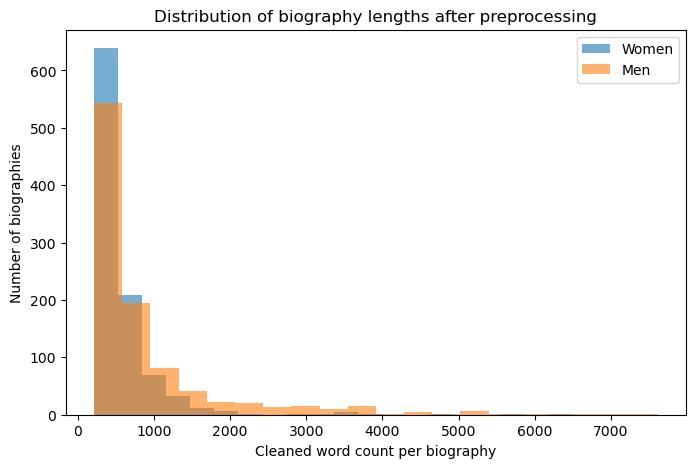

Average cleaned word count by gender:
              count        mean  median  min   max
gender_group                                      
men             980  905.178571   529.5  216  7614
women           980  573.892857   433.0  217  6505


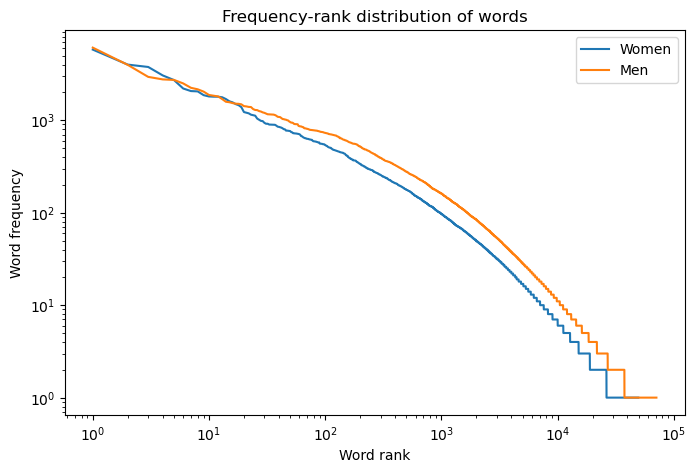


Top 20 words in women biographies:
[('university', 5812), ('research', 4000), ('science', 3771), ('women', 3056), ('work', 2722), ('american', 2206), ('society', 2069), ('award', 2053), ('national', 1869), ('mathematics', 1809), ('professor', 1800), ('school', 1798), ('institute', 1773), ('college', 1695), ('physics', 1603), ('member', 1561), ('chemistry', 1494), ('sciences', 1456), ('received', 1386), ('computer', 1227)]

Top 20 words in men biographies:
[('university', 6106), ('work', 3973), ('science', 2946), ('theory', 2767), ('research', 2731), ('german', 2503), ('published', 2244), ('society', 2162), ('would', 2041), ('mathematics', 1877), ('professor', 1841), ('physics', 1810), ('institute', 1694), ('scientific', 1585), ('history', 1567), ('computer', 1533), ('book', 1511), ('american', 1506), ('sciences', 1487), ('academy', 1422)]

Gendered word usage by gender:
             gendered_word_count               gendered_word_rate            \
                            mean medi

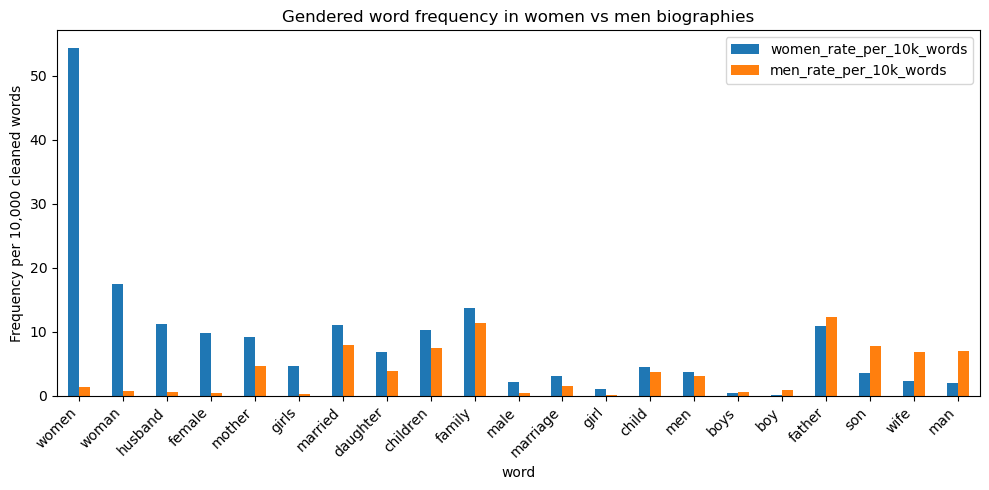


Saved file:
gendered_word_frequency_comparison.csv


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter




plt.figure(figsize=(8, 5))

plt.hist(
    balanced_people[balanced_people["gender_group"] == "women"]["clean_word_count"],
    bins=20,
    alpha=0.6,
    label="Women"
)

plt.hist(
    balanced_people[balanced_people["gender_group"] == "men"]["clean_word_count"],
    bins=20,
    alpha=0.6,
    label="Men"
)

plt.xlabel("Cleaned word count per biography")
plt.ylabel("Number of biographies")
plt.title("Distribution of biography lengths after preprocessing")
plt.legend()
plt.show()


print("Average cleaned word count by gender:")
print(
    balanced_people
    .groupby("gender_group")["clean_word_count"]
    .agg(["count", "mean", "median", "min", "max"])
)




def get_word_frequencies(df):
    """
    Combine all tokens in a dataframe and count word frequencies.
    """

    all_words = []

    for tokens in df["tokens"]:
        all_words.extend(tokens)

    return Counter(all_words)


women_freq = get_word_frequencies(
    balanced_people[balanced_people["gender_group"] == "women"]
)

men_freq = get_word_frequencies(
    balanced_people[balanced_people["gender_group"] == "men"]
)


def plot_frequency_rank(counter, label):
    """
    Plot word frequency by rank.

    Rank 1 = most frequent word.
    """

    frequencies = sorted(counter.values(), reverse=True)
    ranks = range(1, len(frequencies) + 1)

    plt.plot(ranks, frequencies, label=label)


plt.figure(figsize=(8, 5))

plot_frequency_rank(women_freq, "Women")
plot_frequency_rank(men_freq, "Men")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Word rank")
plt.ylabel("Word frequency")
plt.title("Frequency-rank distribution of words")
plt.legend()
plt.show()


print("\nTop 20 words in women biographies:")
print(women_freq.most_common(20))

print("\nTop 20 words in men biographies:")
print(men_freq.most_common(20))



gendered_words = [
    "woman", "women", "female", "girl", "girls",
    "man", "men", "male", "boy", "boys",
    "mother", "father",
    "wife", "husband",
    "married", "marriage",
    "children", "child",
    "family", "daughter", "son"
]


def count_selected_words(tokens, selected_words):
    """
    Count how many times selected words appear in one biography.
    """

    return sum(1 for word in tokens if word in selected_words)


balanced_people["gendered_word_count"] = balanced_people["tokens"].apply(
    lambda tokens: count_selected_words(tokens, gendered_words)
)

balanced_people["gendered_word_rate"] = (
    balanced_people["gendered_word_count"] /
    balanced_people["clean_word_count"]
)


print("\nGendered word usage by gender:")
print(
    balanced_people
    .groupby("gender_group")[["gendered_word_count", "gendered_word_rate"]]
    .agg(["mean", "median", "sum"])
)


# Count each gendered word separately for women and men
rows = []

for word in gendered_words:
    rows.append({
        "word": word,
        "women_count": women_freq.get(word, 0),
        "men_count": men_freq.get(word, 0)
    })

gendered_freq_df = pd.DataFrame(rows)

# Normalize by total number of cleaned words in each group
women_total_words = sum(women_freq.values())
men_total_words = sum(men_freq.values())

gendered_freq_df["women_rate_per_10k_words"] = (
    gendered_freq_df["women_count"] / women_total_words * 10000
)

gendered_freq_df["men_rate_per_10k_words"] = (
    gendered_freq_df["men_count"] / men_total_words * 10000
)

gendered_freq_df["difference_women_minus_men"] = (
    gendered_freq_df["women_rate_per_10k_words"] -
    gendered_freq_df["men_rate_per_10k_words"]
)

gendered_freq_df = gendered_freq_df.sort_values(
    "difference_women_minus_men",
    ascending=False
)

print("\nGendered word frequencies:")
print(gendered_freq_df)


# Bar plot of normalized gendered word frequency
gendered_freq_df.plot(
    x="word",
    y=["women_rate_per_10k_words", "men_rate_per_10k_words"],
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Frequency per 10,000 cleaned words")
plt.title("Gendered word frequency in women vs men biographies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Save result
gendered_freq_df.to_csv("gendered_word_frequency_comparison.csv", index=False)

print("\nSaved file:")
print("gendered_word_frequency_comparison.csv")

# 4. Discussion

## 4.1 Results and discussion

The distribution of cleaned biography lengths shows that both groups follow a similar right-skewed pattern, where most biographies are relatively short and a smaller number are substantially longer. Despite this similarity in shape, there is a consistent difference in average length: biographies of men are longer on average (mean ≈ 905 words) compared to those of women (mean ≈ 574 words). Since longer texts naturally contain more words and more opportunities for co-occurrence, this difference likely contributes to the higher connectivity observed in the men’s network. However, because the overall distributions are similar, the datasets remain broadly comparable. 

Looking at the overall language structure, the frequency–rank distributions for both groups follow a similar Zipf-like pattern. This indicates that the global statistical structure of language is consistent across the two corpora. In other words, both sets of biographies use language in fundamentally similar ways, with a small number of very frequent words and a long tail of rare words. This is an important finding, as it suggests that any differences observed later are not due to differences in general language usage, but rather differences in content—what is being written about.

Examining the most frequent words reinforces this interpretation. Both groups are dominated by terms related to scientific work and institutions, such as *university*, *research*, *science*, and *mathematics*, reflecting the shared domain of the biographies. However, notable differences emerge. the word *women* appears among the most frequent terms in women’s biographies, while men’s biographies place more emphasis on words such as *theory*, *published*, and *scientific*. This suggests that identity related language is more explicitly present in biographies of women, whereas biographies of men focus more strongly on scientific contributions and output.

This difference becomes even clearer when analyzing gendered and familyrelated language. Women’s biographies contain both higher counts and higher normalized rates of gendered words (approximately 1.8% of tokens, compared to 0.8% for men). Words such as *women*, *woman*, and *female* are substantially more frequent in women’s biographies, as are terms related to personal life, including *mother*, *children*, and *married*. In contrast, some gendered terms appear more often in men’s biographies, such as *wife*, *son*, and *man*, but overall these references are less prominent. This indicates that biographies of women scientists place greater emphasis on gender identity and family roles, while mens biographies tend to mention such aspects less frequently or in a different context.

The semantic networks provide a structural perspective on these differences. Both networks are built from the same number of nodes (400 words), ensuring a fair comparison, but they differ in connectivity. The men’s network is more densely connected (density ≈ 0.88) than the women’s network (density ≈ 0.79), meaning that words in men’s biographies co-occur more broadly across contexts. This results in a more interconnected structure where topics are more tightly integrated. In contrast, the slightly lower density of the women’s network suggests a more modular structure, where themes are more clearly separated into distinct clusters.

This structural difference is also reflected in the most central words, measured by weighted degree. In the women’s network, central words include *women*, *american*, *school*, and *national*, highlighting the importance of identity and institutional context. In the menss network, central words such as *theory*, *published*, *scientific*, and *book* emphasize scientific work and output. This further supports the observation that the two groups differ in what aspects of a scientist’s life are highlighted.

Community detection provides additional insight into how these themes are organized. In the women’s network, we observe distinct communities corresponding to education and academic career, institutional recognition and identity, personal and family life, and scientific work. Notably, personal and family-related terms form a clear and separate community, indicating that these topics are treated as a coherent and important aspect of the narrative. In the men’s network, similar themes are present, including scientific work, institutional recognition, and education. However, personal and family-related terms are more dispersed and do not form a clearly defined standalone cluster. Instead, they are integrated into broader thematic groupings.

Taken together, these results suggest that biographies of women and men scientists differ not only in the words that are used, but in how topics are structured and connected. Women’s biographies tend to separate themes such as personal life, recognition, and professional work into distinct clusters, while men’s biographies exhibit a more interconnected structure with a stronger emphasis on scientific contributions. The higher frequency of gendered and family-related language in women’s biographies aligns closely with the presence of a dedicated community for personal life, indicating that these topics are both more frequent and more structurally central.

Overall, the analysis reveals consistent and systematic differences across multiple levelsword frequencies, gendered language usage, network structure, and community organization. These patterns suggest that the observed differences are robust and reflect underlying differences in how scientists are described, rather than being artifacts of a single analytical method.

## 4.2 Critique and Learning Outcomes

A key practical challenge was data collection. Retrieving Wikipedia articles through the API was time-consuming, as requests had to be made sequentially to avoid rate limits. Although bulk requests or multiprocessing could potentially speed up this process, we had issues implementing this succesfully due to time constraints. As a result, the dataset size was constrained by practical limitations. We would like to have implemented that succesfully.

Another important design choice concerns dataset size and sampling. We limited the number of biographies per field and gender group to ensure a balanced dataset. While it would in principle be possible to collect more data, increasing the dataset size would significantly increase computational cost without necessarily improving interpretability. Moreover, the consistency of the observed patterns across multiple analyses suggests that the dataset is sufficiently large to capture some meaningful trends.

The text preprocessing step also introduces subjectivity. In addition to standard stopword removal, we manually extended the stopword list to remove high-frequency but semantically more weak words such as “would”, “could”, and “also”. While this improves the clarity of the semantic networks, it also introduces a bias, as the selection of stopwords reflects our judgment of what constitutes “meaningful” language. Different choices could lead to slightly different network structures...

Similarly, several thresholds were chosen during network construction, including the number of TF-IDF features (400 words), minimum edge weights, and filtering of weak connections. These choices were made in an attempt to balance interpretability and noise reduction. Without such filtering, the networks become overly dense and difficult to interpret. However, these thresholds are not uniquely determined, and different parameter choices could produce alternative network structures. This should probably have been done more systematically or reference theory to support these parameter choices, instead trial and error. So parameter choices could be explored more systematically. Performing a sensitivity analysis would migt help assess how robust the results are to these choices. This is definitely an improvement that could have been implemented. Another improvement is that the network construction could be refined. For example, using sentence-level instead of paragraph-level co-occurrence might produce more precise connections between words, reducing the overall density of the network and improving interpretability. the dataset could be expanded and diversified. Including more biographies, as well as non-English sources, would reduce cultural bias and improve generalizability. While increasing the dataset size comes with computational challenges, it would provide a more representative sample.

Regarding network analysis methods, we focus on weighted degree (node strength) and community detection. While additional measures such as assortativity or more complex centrality metrics ( betweenness or closeness centrality) could be computed, they seem less suitable for this type of semantic co-occurrence network. In this context, nodes represent words, and the interpretation of such measures becomes more unclear. Like there would be no shortest path that would be meaningful as inofmration doesnt "travel". For assortavtivty, it is unclear how this would be interpreted.
Weighted degree provides an interpretable measure of how strongly a word is connected to others, while community detection reveals thematic groupings, which seems to be better for this analysis.



## 4.3 Bias and ethics
Several sources of bias must be considered when interpreting the results of this analysis.

First, the dataset is derived from Wikipedia, which is not a neutral or complete representation of reality. The selection of biographies is influenced by a lot of things such as, editor activity, and the availability of sources. As a result, the dataset is likely biased toward well-documented individuals, which often reflects Western and English-speaking contexts. This is visible in the data, for example through the results of words such as *american* and *german* among the top TF-IDF terms.

Second, the data is subject to historical bias. Many of the biographies span different time periods, and the way scientists are described has changed over time. In particular, for women scientists, references to gender, family, and marital status may reflect historical barriers and societal expectations. For example, mentioning a husband, children, or the fact that a woman was “the first” in a field may have been considered noteworthy in earlier periods, but this may not reflect how contemporary scientists are described. Therefore, the higher frequency of gendered and family-related language in women’s biographies may partly reflect historical context rather than purely linguistic bias.

Third, the data collection process introduces additional bias. Although we attempted to balance the dataset across gender and scientific fields through random sampling, the initial pool of biographies is determined by the Wikidata query and the availability of Wikipedia articles. This means that the sampling is only random within a pre-filtered subset of individuals, and does not actually eliminate underlying selection biases.

Finally, the preprocessing and analysis choices may also introduce bias. For example, the manual stopwords and the selection of TF-IDF features influence which words are included in the analysis. While these steps are necessary to reduce noise and improve interpretability, they also reflect subjective decisions about what constitutes meaningful language.

Overall, these factors highlight that the results should not be interpreted as objective differences between women and men scientists, but rather as differences in how these groups are represented within the Wikipedi biogrpahies. The analysis therefore provides insight into patterns of representation and narrative being told, rather than inherent differences between individuals.:)